# Описание проекта
Вы — маркетинговый аналитик развлекательного приложения Procrastinate Pro+. Несмотря на огромные вложения в рекламу, последние несколько месяцев компания терпит убытки. Ваша задача — разобраться в причинах и помочь компании выйти в плюс.
Есть данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года:
- лог сервера с данными об их посещениях,
- выгрузка их покупок за этот период,
- рекламные расходы.

Нам предстоит изучить:
- откуда приходят пользователи и какими устройствами они пользуются,
- сколько стоит привлечение пользователей из различных рекламных каналов;
- сколько денег приносит каждый клиент,
- когда расходы на привлечение клиента окупаются,
- какие факторы мешают привлечению клиентов.

# Описание данных
В вашем распоряжении три датасета. Файл visits_info_short.csv хранит лог сервера с информацией о посещениях сайта, orders_info_short.csv — информацию о заказах, а costs_info_short.csv — информацию о расходах на рекламу.

Структура visits_info_short.csv:
- User Id — уникальный идентификатор пользователя,
- Region — страна пользователя,
- Device — тип устройства пользователя,
- Channel — идентификатор источника перехода,
- Session Start — дата и время начала сессии,
- Session End — дата и время окончания сессии.

Структура orders_info_short.csv:
- User Id — уникальный идентификатор пользователя,
- Event Dt — дата и время покупки,
- Revenue — сумма заказа.

Структура costs_info_short.csv:
- dt — дата проведения рекламной кампании,
- Channel — идентификатор рекламного источника,
- costs — расходы на эту кампанию.

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Шаг 1. Загрузка данных и подготовка их к анализу

In [ ]:
try:
    visits, orders,  costs =  (
        pd.read_csv('../data/visits_info_short.csv'),  # журнал сессий
        pd.read_csv('../data/orders_info_short.csv'),  # покупки
        pd.read_csv('../data/costs_info_short.csv')  # траты на рекламу
    )
except:
    visits, orders,  costs =  (
        pd.read_csv('../data/visits_info_short.csv'),  # журнал сессий
        pd.read_csv('../data/orders_info_short.csv'),  # покупки
        pd.read_csv('../data/costs_info_short.csv')  # траты на рекламу
    )

In [ ]:
visits

             User Id         Region   Device         Channel  \
0       981449118918  United States   iPhone         organic   
1       278965908054  United States   iPhone         organic   
2       590706206550  United States      Mac         organic   
3       326433527971  United States  Android          TipTop   
4       349773784594  United States      Mac         organic   
...              ...            ...      ...             ...   
309896  329994900775             UK       PC         LeapBob   
309897  334903592310         France       PC  lambdaMediaAds   
309898  540102010126        Germany       PC         organic   
309899  308736936846        Germany      Mac         organic   
309900  109329042535        Germany       PC  lambdaMediaAds   

              Session Start          Session End  
0       2019-05-01 02:36:01  2019-05-01 02:45:01  
1       2019-05-01 04:46:31  2019-05-01 04:47:35  
2       2019-05-01 14:09:25  2019-05-01 15:32:08  
3       2019-05-01 00:29:59

In [ ]:
orders

            User Id             Event Dt  Revenue
0      188246423999  2019-05-01 23:09:52     4.99
1      174361394180  2019-05-01 12:24:04     4.99
2      529610067795  2019-05-01 11:34:04     4.99
3      319939546352  2019-05-01 15:34:40     4.99
4      366000285810  2019-05-01 13:59:51     4.99
...             ...                  ...      ...
40207  651604369137  2019-10-31 16:19:07     4.99
40208  275341387049  2019-10-31 01:17:17     4.99
40209  374656616484  2019-10-31 06:17:29     4.99
40210  168548862926  2019-10-31 22:46:19     4.99
40211  329994900775  2019-10-31 13:29:06     4.99

[40212 rows x 3 columns]

In [ ]:
costs

              dt         Channel  costs
0     2019-05-01        FaceBoom  113.3
1     2019-05-02        FaceBoom   78.1
2     2019-05-03        FaceBoom   85.8
3     2019-05-04        FaceBoom  136.4
4     2019-05-05        FaceBoom  122.1
...          ...             ...    ...
1795  2019-10-23  lambdaMediaAds    4.0
1796  2019-10-24  lambdaMediaAds    6.4
1797  2019-10-25  lambdaMediaAds    8.8
1798  2019-10-26  lambdaMediaAds    8.8
1799  2019-10-27  lambdaMediaAds   12.0

[1800 rows x 3 columns]

In [ ]:
# изменим название колонок на змеиный регист, также устаановим только строчные буквы
visits.columns = [x.lower().replace(' ', '_') for x in visits.columns.values]
orders.columns = [x.lower().replace(' ', '_') for x in orders.columns.values]
costs.columns = [x.lower().replace(' ', '_') for x in costs.columns.values]

In [ ]:
# преобразование данных о времени
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
costs['dt'] = pd.to_datetime(costs['dt'])

In [ ]:
# проверяем на пропуски
visits.info()
orders.info()
costs.info()
# во всех таблицах отсутствуют пропуски

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.

In [ ]:
# Проверим на дубликаты по столбцам времени и индефикатора, так как покупки могли совершаться несколько раз важно учитывать и время совершения для выявления дубликатов 
visits[visits.duplicated(subset=['user_id', 'session_start'], keep=False)]
visits[visits.duplicated(subset=['user_id', 'session_end'], keep=False)]
orders[orders.duplicated(subset=['user_id', 'event_dt'], keep=False)]
costs[costs.duplicated(subset=['dt', 'channel', 'costs'], keep=False)]

Empty DataFrame
Columns: [dt, channel, costs]
Index: []

Вывод:
- Явных дубликатов нет
- Пропусков нет
- Типы данных изменены там, где это необходимо
- Названия столбцов изменены в соответствии с правильным тоном Питона

#  Функции для расчёта и анализа LTV, ROI, удержания и конверсии.

### Функция для создания пользовательских профилей

In [ ]:
def get_profiles(visits, orders, ad_costs):
    # находим параметры первых посещений
    visits['session_start'] = pd.to_datetime(visits['session_start'])
    visits['session_end'] = pd.to_datetime(visits['session_end'])
    orders['event_dt'] = pd.to_datetime(orders['event_dt'])
    costs['dt'] = pd.to_datetime(costs['dt'])
    profiles = (
        visits.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['first_ts'] = pd.to_datetime(profiles['first_ts'])
    profiles['dt'] = profiles['first_ts'].dt.date  
    profiles['month'] = profiles['first_ts'].dt.month  

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    ad_costs['dt'] = ad_costs['dt'].dt.date
    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

### Функция для расчёта удержания

In [ ]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

### Функция для расчёта конверсии

In [ ]:
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 

### Функция для расчёта LTV и ROI

In [ ]:
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    ) 

# Функции для визуализации

In [ ]:
# функция для сглаживания фрейма

def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

In [ ]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show() 

In [ ]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

In [ ]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

# Шаг 3. Исследовательский анализ данных


In [ ]:
# Составbv профили пользователей. Определиv минимальную и максимальную даты привлечения пользователей.
result_profiles = get_profiles(visits, orders, costs)
result_profiles

             user_id            first_ts       channel  device         region  \
0             599326 2019-05-07 20:58:57      FaceBoom     Mac  United States   
1            4919697 2019-07-09 12:46:07      FaceBoom  iPhone  United States   
2            6085896 2019-10-01 09:58:33       organic  iPhone         France   
3           22593348 2019-08-22 21:35:48    AdNonSense      PC        Germany   
4           31989216 2019-10-02 00:07:44       YRabbit  iPhone  United States   
...              ...                 ...           ...     ...            ...   
150003  999956196527 2019-09-28 08:33:02        TipTop  iPhone  United States   
150004  999975439887 2019-10-21 00:35:17       organic      PC             UK   
150005  999976332130 2019-07-23 02:57:06        TipTop  iPhone  United States   
150006  999979924135 2019-09-28 21:28:09  MediaTornado      PC  United States   
150007  999999563947 2019-10-18 19:57:25       organic  iPhone  United States   

                dt  month  

In [ ]:
min_dt_profiles = result_profiles['first_ts'].min()
max_dt_profiles = result_profiles['first_ts'].max()

In [ ]:
print('Минимальная дата привлечения клиентов:',min_dt_profiles)
print('Максимальная дата привлечения клиентов:',max_dt_profiles)

Минимальная дата привлечения клиентов: 2019-05-01 00:00:41
Максимальная дата привлечения клиентов: 2019-10-27 23:59:04


**Вывод:** 
Данные о пользователях, соответствую заявленным ТЗ. Пользователи привлечённы с 1 мая по 27 октября 2019 года.

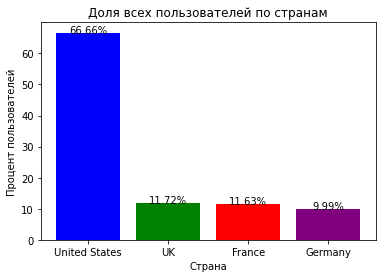

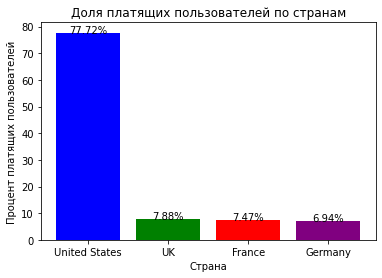

In [ ]:
# Сгруппируем регионы по количеству пользователей и сумме платящих по пользователям
country_result = result_profiles.groupby('region').agg({'user_id': 'count', 'payer': 'sum'}).sort_values(by='user_id', ascending=False)

# Рассчитаем процентное соотношение пользователей от общего числа пользователей
country_result['user_percentage'] = (country_result['user_id'] / country_result['user_id'].sum()) * 100

# Рассчитаем процентное соотношение платящих пользователей от общего числа платящих пользователей
country_result['payer_percentage'] = (country_result['payer'] / country_result['payer'].sum()) * 100

# Построим столбчатую диаграмму, чтобы посмотреть долю всех пользователей по странам
fig1, ax1 = plt.subplots()
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
ax1.bar(country_result.index, country_result['user_percentage'], color=bar_colors)
for i, v in enumerate(country_result['user_percentage']):
    ax1.text(i, v , str(round(v, 2)) + '%', color='black', ha='center')
ax1.set_xlabel('Страна')
ax1.set_ylabel('Процент пользователей')
ax1.set_title('Доля всех пользователей по странам')

# Построим столбчатую диаграмму, чтобы посмотреть долю платящих пользователей по странам
fig2, ax2 = plt.subplots()
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
ax2.bar(country_result.index, country_result['payer_percentage'], color=bar_colors)
for i, v in enumerate(country_result['payer_percentage']):
    ax2.text(i, v , str(round(v, 2)) + '%', color='black', ha='center')
ax2.set_xlabel('Страна')
ax2.set_ylabel('Процент платящих пользователей')
ax2.set_title('Доля платящих пользователей по странам')

plt.show()

In [ ]:
country_result['payer']

region
United States    6902
UK                700
France            663
Germany           616
Name: payer, dtype: int64

In [ ]:
country_result['payer_percent']=country_result['payer']/country_result['user_id']*100
country_result

               user_id  payer  user_percentage  payer_percentage  \
region                                                             
United States   100002   6902        66.664445         77.716473   
UK               17575    700        11.716042          7.881995   
France           17450    663        11.632713          7.465376   
Germany          14981    616         9.986801          6.936156   

               payer_percent  
region                        
United States       6.901862  
UK                  3.982930  
France              3.799427  
Germany             4.111875  

**Вывод:** 
- Среди пользователей приложения США имеют большую долю, как платящих клиентов (77,7%), так и неплатящих клиентов (66,7%).
- Англия, Франция и Германия имеют относительно равные показатели в обеих категориях.
- Согласно данным, в США клиенты платят чаще остальных (6,9%), а вот во Франции этот показатель худший среди приведенных (3.8%).

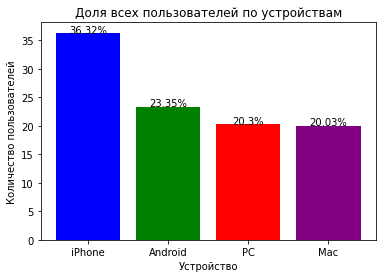

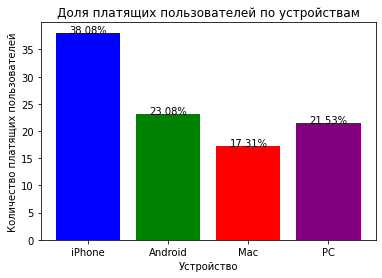

In [ ]:
# Сгруппируем регионы по количеству пользователей и сумме платящих по пользователям
device_result = result_profiles.groupby('device').agg({'user_id': 'count', 'payer': 'sum'}).sort_values(by='user_id', ascending=False)

device_result['user_percentage'] = (device_result['user_id'] / device_result['user_id'].sum()) * 100
device_result['payer_percentage'] = (device_result['payer'] / device_result['payer'].sum()) * 100
# Построим столбчатую диаграмму, чтобы посмотреть долю всех пользователей по устройствам
fig1, ax1 = plt.subplots()
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
ax1.bar(device_result.index, device_result['user_percentage'], color=bar_colors)
for i, v in enumerate(device_result['user_percentage']):
    ax1.text(i, v , str(round(v, 2)) + '%', color='black', ha='center')
ax1.set_xlabel('Устройство')
ax1.set_ylabel('Количество пользователей')
ax1.set_title('Доля всех пользователей по устройствам')

# Построим столбчатую диаграмму, чтобы посмотреть долю платящих пользователей по устройствам
fig2, ax2 = plt.subplots()
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
device_result_sorted = device_result.sort_values(by='payer', ascending=False)
ax2.bar(device_result_sorted.index, device_result['payer_percentage'], color=bar_colors)
for i, v in enumerate(device_result['payer_percentage']):
    ax2.text(i, v , str(round(v, 2)) + '%', color='black', ha='center')
ax2.set_xlabel('Устройство')
ax2.set_ylabel('Количество платящих пользователей')
ax2.set_title('Доля платящих пользователей по устройствам')

plt.show()

In [ ]:
device_result['payer_percent']=device_result['payer']/device_result['user_id']*100
device_result

         user_id  payer  user_percentage  payer_percentage  payer_percent
device                                                                   
iPhone     54479   3382        36.317396         38.081297       6.207897
Android    35032   2050        23.353421         23.082986       5.851793
PC         30455   1537        20.302251         17.306610       5.046790
Mac        30042   1912        20.026932         21.529107       6.364423

**Вывод:**
- Среди пользователей приложения чаще пользуются мобильными устройствами (36.2% iPhone и 23.35 Android), чем компьютерами (20.3 у Mac и PC).
- iPhone является самым популярным устройством у клиентов, как у платящих, так и у неплатящихх
- Согласно данным, независимо от устройств, в платящие переходят всего 5-6%.

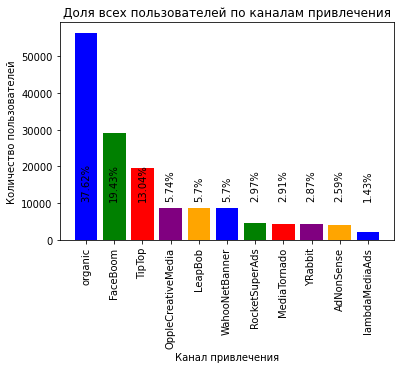

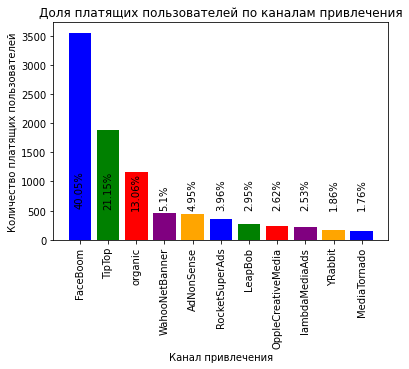

In [ ]:
# Calculate the percentage of users and payers per channel
channel_result = result_profiles.groupby('channel').agg({'user_id': 'count', 'payer': 'sum'}).sort_values(by='user_id', ascending=False)

channel_result['user_percentage'] = (channel_result['user_id'] / channel_result['user_id'].sum()) * 100
channel_result['payer_percentage'] = (channel_result['payer'] / channel_result['payer'].sum()) * 100

# Plot the bar chart to see the share of all users by acquisition channel
fig1, ax1 = plt.subplots()
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
ax1.bar(channel_result.index, channel_result['user_id'], color=bar_colors)
for i, v in enumerate(channel_result['user_percentage']):
    ax1.text(i, v+ 10500, str(round(v, 2)) + '%', color='black', ha='center', va='bottom', rotation=90)  # Поворачиваем надписи на 90 градусов
ax1.set_xlabel('Канал привлечения')
ax1.set_ylabel('Количество пользователей')
ax1.set_title('Доля всех пользователей по каналам привлечения')
ax1.tick_params(axis='x', rotation=90)  # Поворачиваем подписи на оси x под углом 90 градусов

# Plot the bar chart to see the share of paying users by acquisition channel
fig2, ax2 = plt.subplots()
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
channel_result_sorted = channel_result.sort_values(by='payer', ascending=False)
ax2.bar(channel_result_sorted.index, channel_result_sorted['payer'], color=bar_colors)
for i, v in enumerate(channel_result_sorted['payer_percentage']):
    ax2.text(i, v+500, str(round(v, 2)) + '%', color='black', ha='center', va='bottom', rotation=90)  # Поворачиваем надписи на 90 градусов
ax2.set_xlabel('Канал привлечения')
ax2.set_ylabel('Количество платящих пользователей')
ax2.set_title('Доля платящих пользователей по каналам привлечения')
ax2.tick_params(axis='x', rotation=90)  # Поворачиваем подписи на оси x под углом 90 градусов

plt.show()

In [ ]:
channel_result['payer_percent']=channel_result['payer']/channel_result['user_id']*100
channel_result

                    user_id  payer  user_percentage  payer_percentage  \
channel                                                                 
organic               56439   1160        37.623993         13.061592   
FaceBoom              29144   3557        19.428297         40.051796   
TipTop                19561   1878        13.039971         21.146267   
OppleCreativeMedia     8605    233         5.736361          2.623578   
LeapBob                8553    262         5.701696          2.950118   
WahooNetBanner         8553    453         5.701696          5.100777   
RocketSuperAds         4448    352         2.965175          3.963518   
MediaTornado           4364    156         2.909178          1.756559   
YRabbit                4312    165         2.874513          1.857899   
AdNonSense             3880    440         2.586529          4.954397   
lambdaMediaAds         2149    225         1.432590          2.533498   

                    payer_percent  
channel       

**Вывод:**
- Среди всех пользователей, Органических - почти 56500, второе и третье место пользователей привлечены через каналы FaceBoom и TipTop- 29144 и 19561.
- Наибольшая доля платящих клиентов пренадлежат каналам FaceBoom, AdNonSense и lambdaMediaAds превыщают 10%, причем 2 последних канала находятся на последних местах по количеству пользователей.
- Не смотря на то, что ~53% пользователей не были привлечены рекламой, 2% из них остаются платящими.

# Шаг 4. Маркетинг

In [ ]:
# Посчитаем общую сумму расходов на маркетинг.
costs_result = costs['costs'].sum().round(1)
print('Общая сумма затрат на рекламу составляет:',costs_result)

Общая сумма затрат на рекламу составляет: 105497.3


In [ ]:
costs_advert = result_profiles.groupby('channel').agg({'acquisition_cost':'sum'}).sort_values(by='acquisition_cost', ascending=False)
costs_advert

                    acquisition_cost
channel                             
TipTop                      54751.30
FaceBoom                    32445.60
WahooNetBanner               5151.00
AdNonSense                   3911.25
OppleCreativeMedia           2151.25
RocketSuperAds               1833.00
LeapBob                      1797.60
lambdaMediaAds               1557.60
MediaTornado                  954.48
YRabbit                       944.22
organic                         0.00

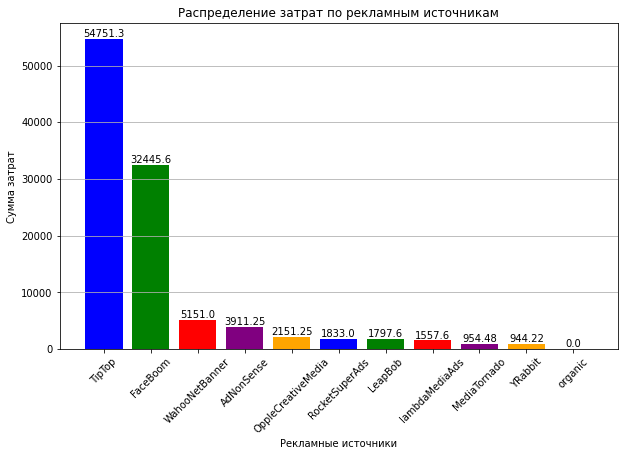

In [ ]:
# Создание графика
plt.figure(figsize=(10, 6))
bar_colors = ['blue', 'green', 'red', 'purple', 'orange']
bars = plt.bar(costs_advert.index, costs_advert['acquisition_cost'], color=bar_colors)

# Добавление подписей с количеством над каждым столбцом
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Настройки графика
plt.xlabel('Рекламные источники')
plt.ylabel('Сумма затрат')
plt.title('Распределение затрат по рекламным источникам')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Отображение графика
plt.show()

**Вывод:**
- Более 50% было потрачено канал TipTop.
- Траты на рекламу на каналах TipTop и FaceBoom составляют 83%.
- Траты на остальные каналы более вменяемые составляют не более 5200$. 

In [ ]:
result_profiles

             user_id            first_ts       channel  device         region  \
0             599326 2019-05-07 20:58:57      FaceBoom     Mac  United States   
1            4919697 2019-07-09 12:46:07      FaceBoom  iPhone  United States   
2            6085896 2019-10-01 09:58:33       organic  iPhone         France   
3           22593348 2019-08-22 21:35:48    AdNonSense      PC        Germany   
4           31989216 2019-10-02 00:07:44       YRabbit  iPhone  United States   
...              ...                 ...           ...     ...            ...   
150003  999956196527 2019-09-28 08:33:02        TipTop  iPhone  United States   
150004  999975439887 2019-10-21 00:35:17       organic      PC             UK   
150005  999976332130 2019-07-23 02:57:06        TipTop  iPhone  United States   
150006  999979924135 2019-09-28 21:28:09  MediaTornado      PC  United States   
150007  999999563947 2019-10-18 19:57:25       organic  iPhone  United States   

                dt  month  

In [ ]:
# преобразуем данные во времянной формат
result_profiles['dt'] = pd.to_datetime(result_profiles['dt'])
result_profiles['week'] = result_profiles['dt'].dt.isocalendar().week
result_profiles['month'] = result_profiles['dt'].dt.month
result_profiles

             user_id            first_ts       channel  device         region  \
0             599326 2019-05-07 20:58:57      FaceBoom     Mac  United States   
1            4919697 2019-07-09 12:46:07      FaceBoom  iPhone  United States   
2            6085896 2019-10-01 09:58:33       organic  iPhone         France   
3           22593348 2019-08-22 21:35:48    AdNonSense      PC        Germany   
4           31989216 2019-10-02 00:07:44       YRabbit  iPhone  United States   
...              ...                 ...           ...     ...            ...   
150003  999956196527 2019-09-28 08:33:02        TipTop  iPhone  United States   
150004  999975439887 2019-10-21 00:35:17       organic      PC             UK   
150005  999976332130 2019-07-23 02:57:06        TipTop  iPhone  United States   
150006  999979924135 2019-09-28 21:28:09  MediaTornado      PC  United States   
150007  999999563947 2019-10-18 19:57:25       organic  iPhone  United States   

               dt  month  p

In [ ]:
#Сгруппируем данныe о недельных и месячных затратах на рекламу
weekly_spending = result_profiles.groupby(['channel', 'week'])['acquisition_cost'].sum().reset_index()
monthly_spending = result_profiles.groupby(['channel', 'month'])['acquisition_cost'].sum().reset_index()
weekly_spending

        channel  week  acquisition_cost
0    AdNonSense    18            211.05
1    AdNonSense    19            273.00
2    AdNonSense    20            265.65
3    AdNonSense    21            266.70
4    AdNonSense    22            202.65
..          ...   ...               ...
281     organic    39              0.00
282     organic    40              0.00
283     organic    41              0.00
284     organic    42              0.00
285     organic    43              0.00

[286 rows x 3 columns]

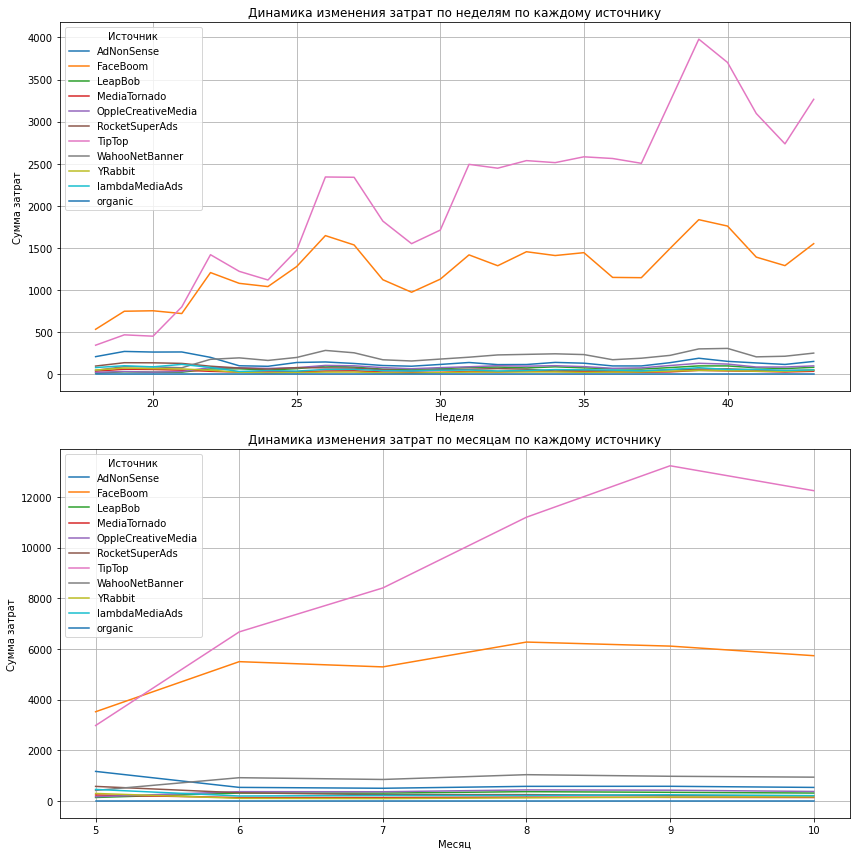

In [ ]:
# Создание subplots с двумя графиками
fig, axs = plt.subplots(2, figsize=(12, 12))

# График по неделям
for channel, data in weekly_spending.groupby('channel'):
    axs[0].plot(data['week'], data['acquisition_cost'], label=channel)

# Настройки графика по неделям
axs[0].set_xlabel('Неделя')
axs[0].set_ylabel('Сумма затрат')
axs[0].set_title('Динамика изменения затрат по неделям по каждому источнику')
axs[0].legend(title='Источник')
axs[0].grid()

# График по месяцам
for channel, data in monthly_spending.groupby('channel'):
    axs[1].plot(data['month'], data['acquisition_cost'], label=channel)

# Настройки графика по месяцам
axs[1].set_xlabel('Месяц')
axs[1].set_ylabel('Сумма затрат')
axs[1].set_title('Динамика изменения затрат по месяцам по каждому источнику')
axs[1].legend(title='Источник')
axs[1].grid()

# Отображение графиков
plt.tight_layout()
plt.show()

**Вывод**
- Затраты на TipTop и FaceBoom увеличивались еженедельно и ежемесячно.
- Неадекватные затраты на TipTop, если в начале мая траты составляли порядка 3500, то в октябре сумма достигла более 12000, с FaceBoom  хоть траты и увеличивались, сумма к концу октября составляла 6000, что на более 2000 больше, по сравнению с маем.
- По остальным рекламным источникам траты были крайне скромными, если сравнивать с TipTop и FaceBoom, минимальная сумма в неделю была 15 единиц, а максимальная около 300, в месяц минимальная около 100, а максимум около 1000.

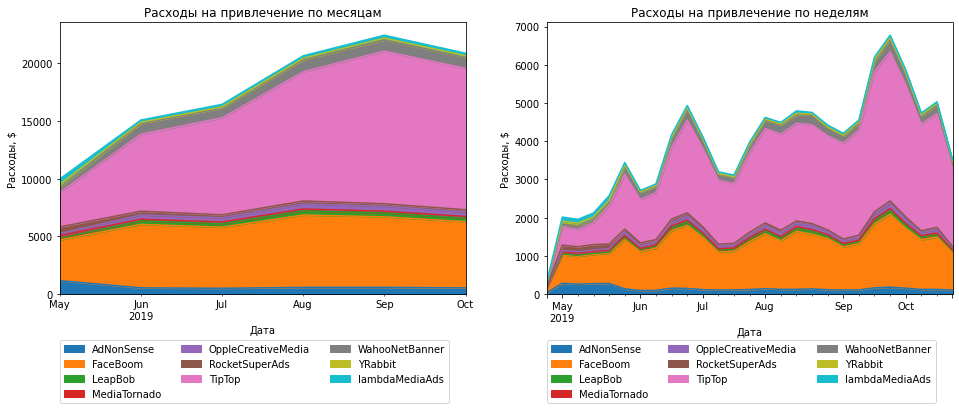

In [ ]:


costs['Расходы на привлечение по месяцам'] = costs['dt'].astype('datetime64[M]')
costs['Расходы на привлечение по неделям'] = costs['dt'].astype('datetime64[W]')

columns = ['Расходы на привлечение по месяцам', 'Расходы на привлечение по неделям']

plt.subplots(figsize = (16, 5))
for i, col in enumerate(columns):
    costs.pivot_table(index = col, columns = 'channel', values = 'costs', 
                      aggfunc = 'sum').plot.area(ax = plt.subplot(1, 2, i + 1))
    plt.title(col)
    plt.xlabel('Дата')
    plt.ylabel('Расходы, $')
    plt.legend(ncol=3, bbox_to_anchor=(0, -0.4), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
costs_advert_mean = result_profiles.groupby('channel').agg({'acquisition_cost':'mean'}).sort_values(by='acquisition_cost', ascending=False).reset_index()
costs_advert_mean

               channel  acquisition_cost
0               TipTop          2.799003
1             FaceBoom          1.113286
2           AdNonSense          1.008054
3       lambdaMediaAds          0.724802
4       WahooNetBanner          0.602245
5       RocketSuperAds          0.412095
6   OppleCreativeMedia          0.250000
7              YRabbit          0.218975
8         MediaTornado          0.218717
9              LeapBob          0.210172
10             organic          0.000000

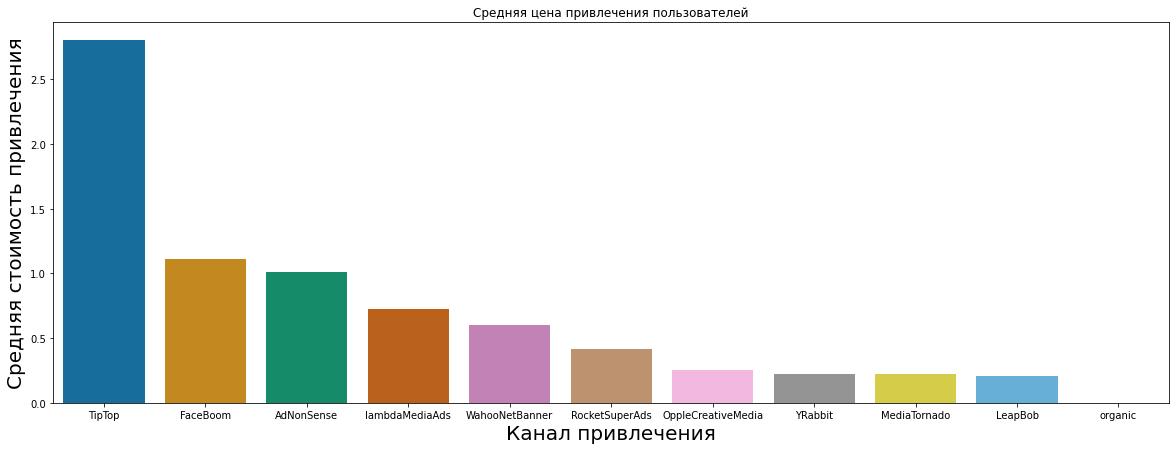

In [ ]:
plt.figure(figsize=(20,7))
plt.title('Средняя цена привлечения пользователей')
sns.barplot(data=costs_advert_mean, x='channel', y='acquisition_cost', palette='colorblind')
plt.xlabel('Канал привлечения', fontsize=20)
plt.ylabel('Средняя стоимость привлечения', fontsize=20);

**Вывод:**
- Больше всего на привлечение пользователя было потрачено на канал TipTop, 2.8$

- В то врем как из других источников пользователи обходились ~1$.

# Шаг 5. Оценим окупаемость рекламы

In [ ]:
#на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения.
#исключим органические источники, так как они равны 0 и могут исказить аналищ
result_profiles = result_profiles.query('channel != "organic"')
observation_date = datetime(2019, 11, 1).date()  
horizon_days = 14 

### Показатели окупаемости рекламы LTV и ROI, графики динамики LTV, CAC и ROI.

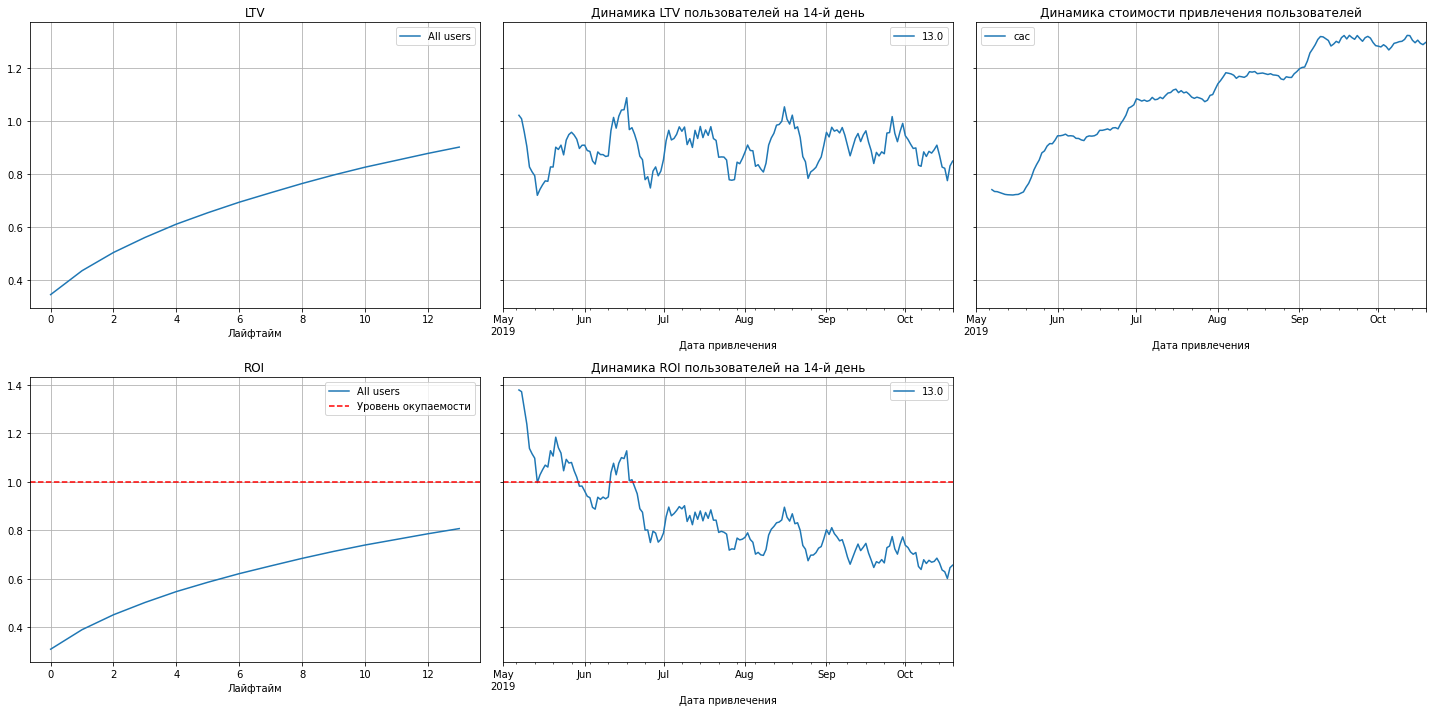

In [ ]:
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    result_profiles, orders, observation_date, horizon_days
)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

**Вывод:**
- Показатели LTV в порядке, с увеличением лайфайма показатель растет.
- Стоимость привлечения пользователя с мая поступательно растет, но это никак не окупается, ROI ниже уровня окупаемости.

### Анализируем показатели конверсии с разбивкой по устройствам, странам и каналам привлечения.

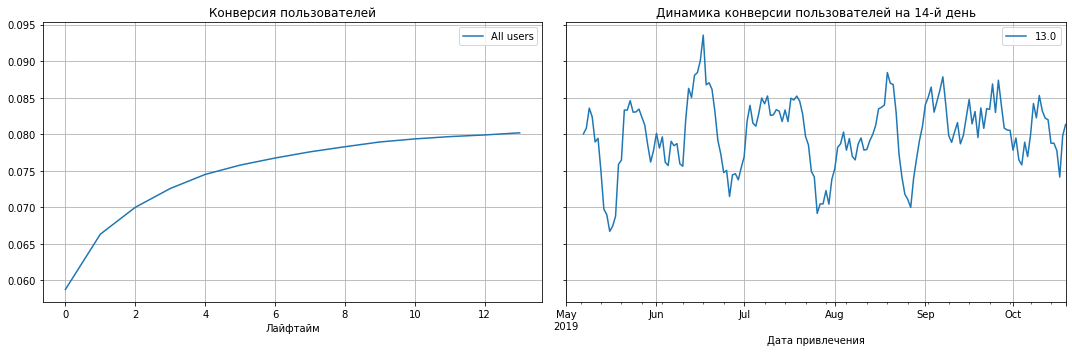

In [ ]:
# смотрим конверсию
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    result_profiles, orders, observation_date, horizon_days)

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

**Вывод:**
- Показатели конверсии хорошие. Конверсия растет, значит большая часть посетителей делает то, что от них ожидают.
- Хорошая конвертация происходит за первые 4 дня, потом показатели выравниваются, но все равно растут.

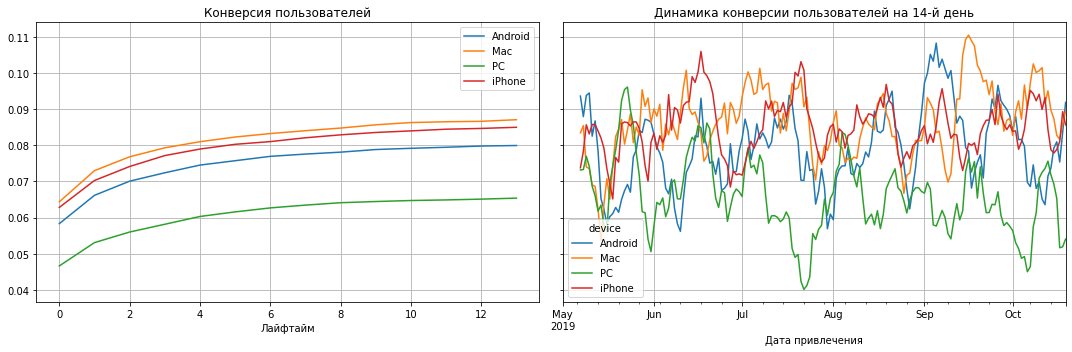

In [ ]:
# смотрим конверсию по устройствам
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    result_profiles, orders, observation_date, horizon_days, dimensions=['device'])

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

**Вывод:**
- Лучшую конвертацию показывают пользователи Мас, причем на протяжении врего времени.

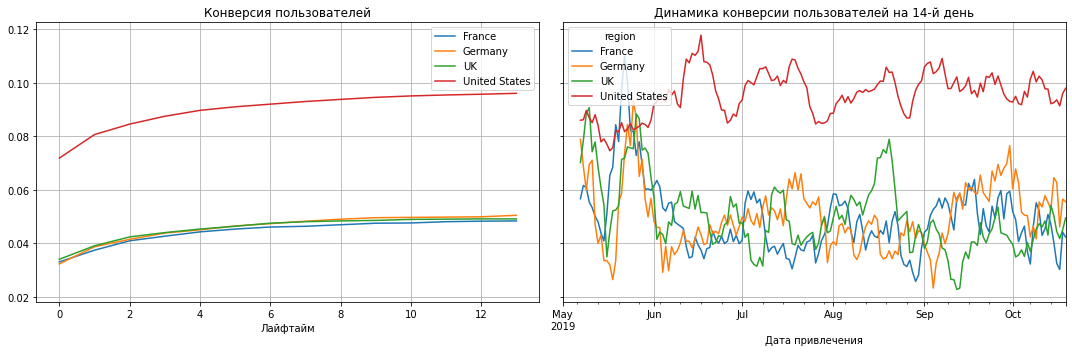

In [ ]:
# смотрим конверсию по странам
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    result_profiles, orders, observation_date, horizon_days, dimensions=['region'])

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

**Вывод:**
- Интересное наблюдение- конверсия пользователей Германии, Англии и Франции рядом не стоят с конверсией США, но если посмотреть на динамику, то во второй половине мая конверсия этих стран была выше США.

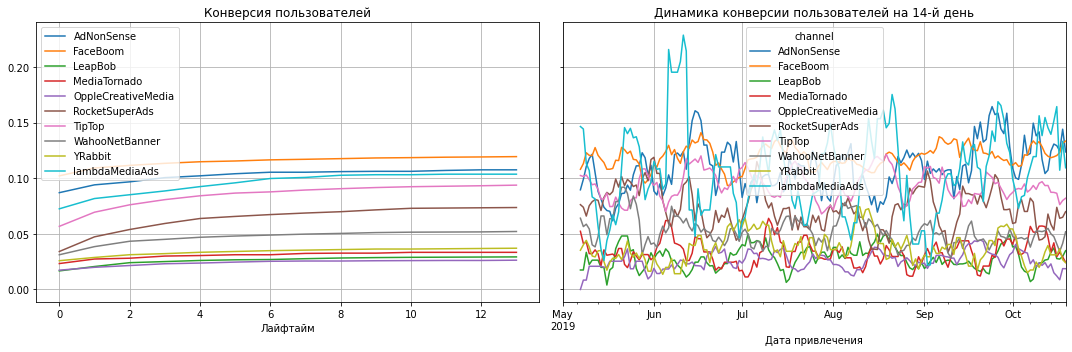

In [ ]:
# смотрим конверсию по каналу привлечения
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    result_profiles, orders, observation_date, horizon_days, dimensions=['channel'])

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

**Вывод:**
- Худшие результаты конверсии у каналов OppleCreativeMedia, MediaTornado, LeapBob, YRabbit
- Динамика конверсии lambdaMediaAds нестабильна, постоянны взлеты, затем резкие спады на протяжении всего времени.

### Анализируем показатели удержания клиента с разбивкой по устройствам, странам и каналам привлечения.

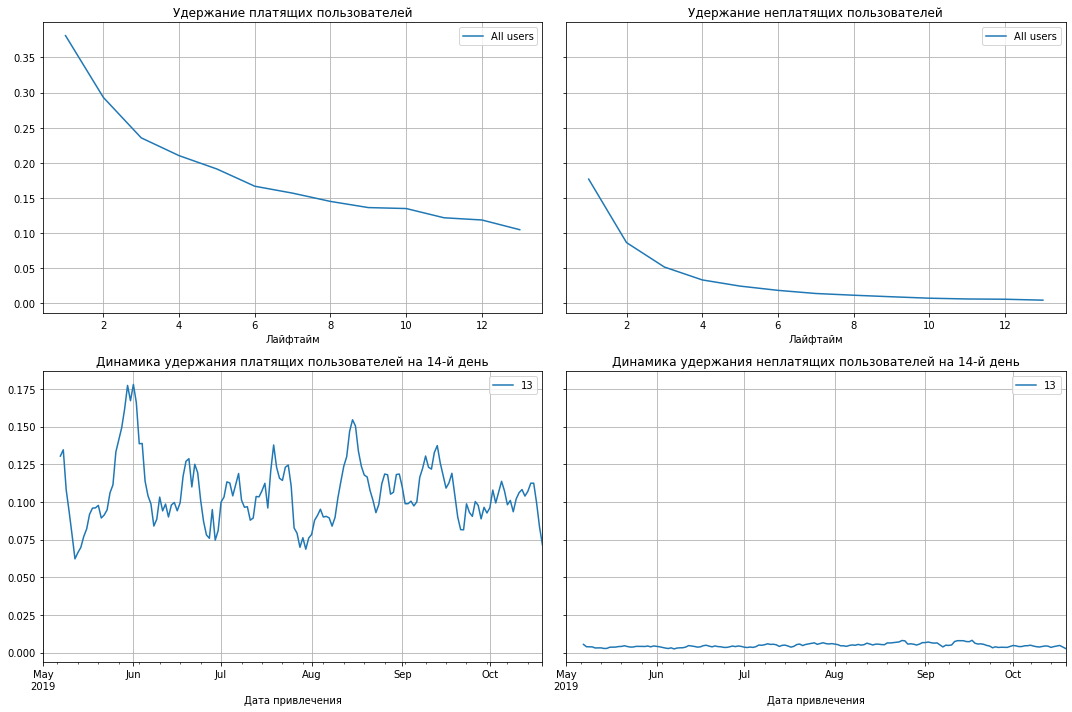

In [ ]:
# смотрим удержание

retention_raw, retention_grouped, retention_history = get_retention(
    result_profiles, visits, observation_date, horizon_days)

plot_retention(retention_grouped, retention_history, horizon_days)

**Вывод:**
1) Удержание платящих пользователей  первый день составляет более 35%. На 13й день остается всего 10%.
2) У неплатящих динамика удержания низкая. Вероятно, ограниченные возможности и отсутствией акций и привилегий, чем у платящих пользователей.

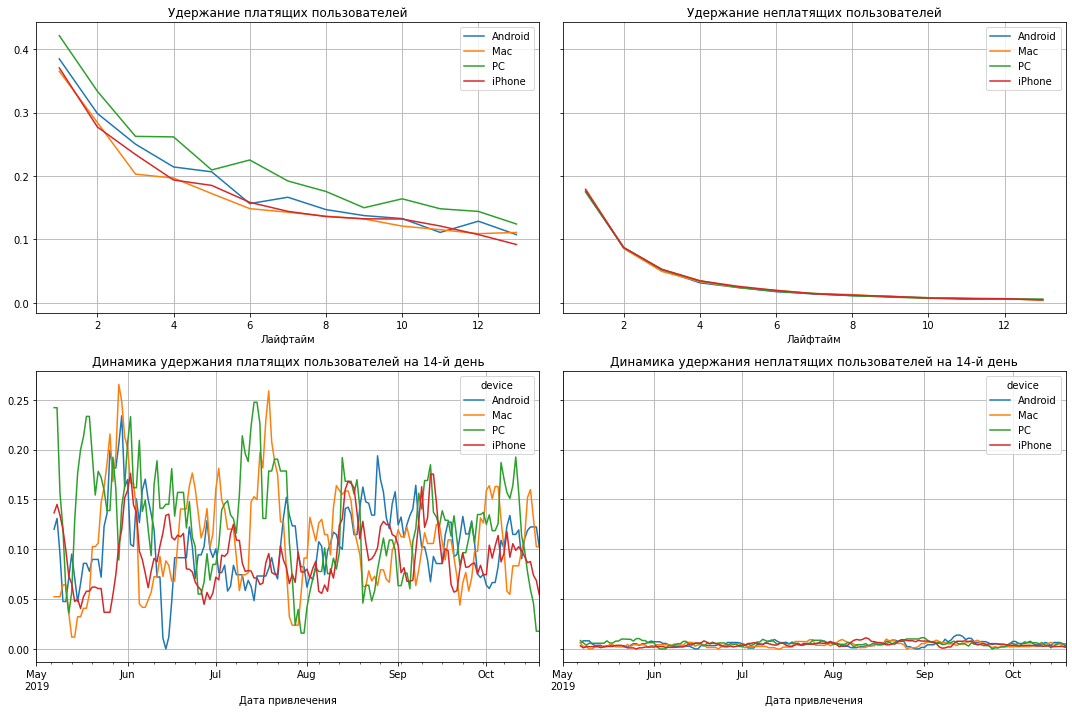

In [ ]:
# смотрим удержание с разбивкой по устройствам

retention_raw, retention_grouped, retention_history = get_retention(
    result_profiles, visits, observation_date, horizon_days, dimensions=['device']
)

plot_retention(retention_grouped, retention_history, horizon_days)

**Вывод:**
1) График удержания платящих не резкий, пользователи PC удерживаются лучше остальных, при том, что по количеству занимает 3юю строчку.
2) Динамика очень резкая, стоит отметить тот факт, что в середине июля удержания пользователей андроида была равна 0, скорее показатель связан с массовым сбоем.
3) По неплатящим пользователям показатели практически одинаковы.

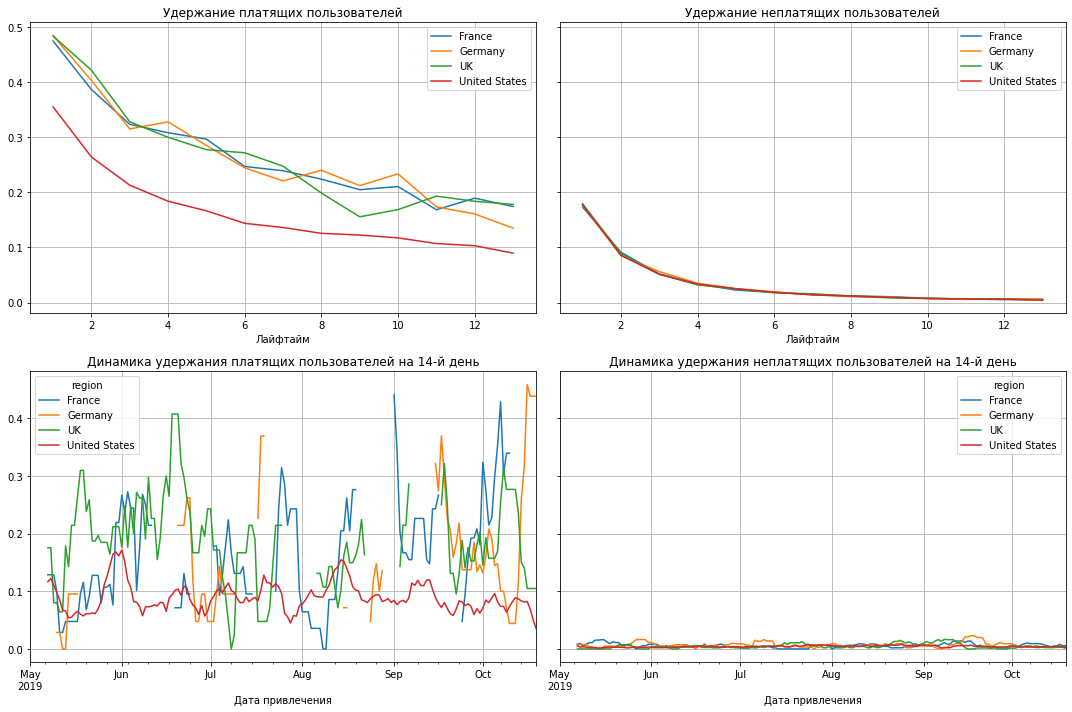

In [ ]:
# смотрим удержание с разбивкой по странам

retention_raw, retention_grouped, retention_history = get_retention(
    result_profiles, visits, observation_date, horizon_days, dimensions=['region']
)

plot_retention(retention_grouped, retention_history, horizon_days)

**Вывод:**
- Вот и первый сигнал убыткой компании- платящие клиенты из США удерживаются хуже остальных, при том, что основная масса пользователей приложения проживает в этом регионе.
- Также присутствуют разрывы в графиках, возможно это происходит из-за отсутствия поддержки после продажи, так как уклон сделан на регион с большим количеством клиентов.

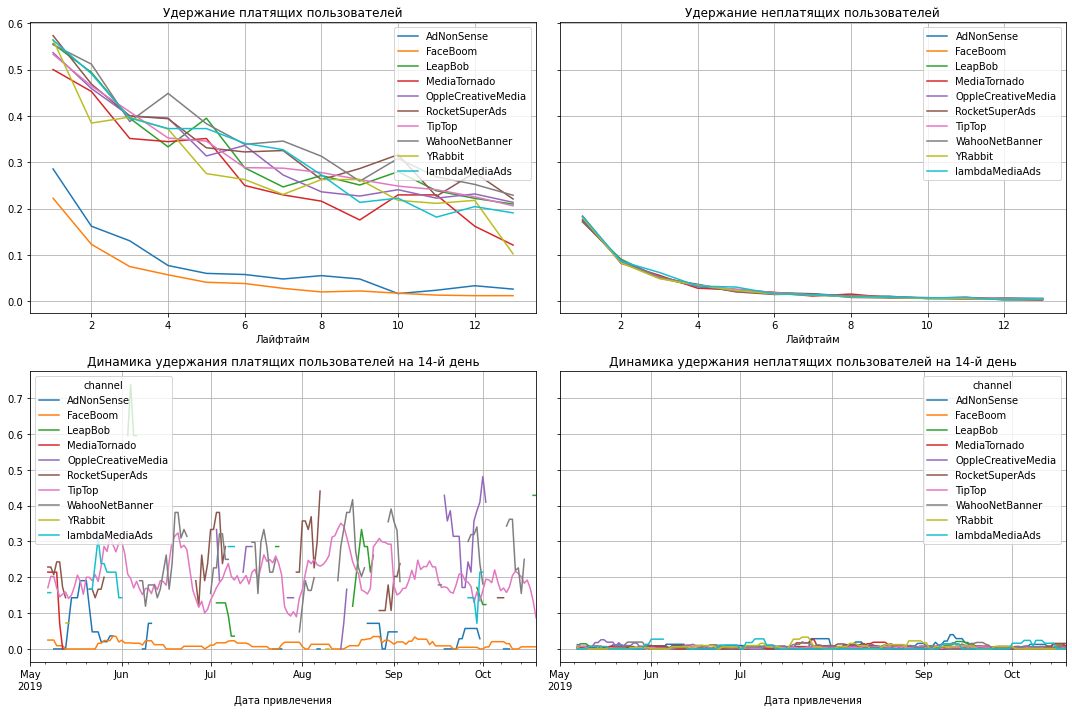

In [ ]:
# смотрим удержание с разбивкой по каналу привлечения

retention_raw, retention_grouped, retention_history = get_retention(
    result_profiles, visits, observation_date, horizon_days, dimensions=['channel']
)

plot_retention(retention_grouped, retention_history, horizon_days)

**Вывод:**
- FaceBoom и AdNonSens являются топ-2 и топ-3 каналами привлечения по стоимости и при этом показывают худщее удержание с худшим стартовым коэффицентом.
- С динамикой проблема такая же, как и со странами, частые разрывы для 14 дневного показателя, только TipTop и FaceBoom идет без прерываний.

### Анализируем окупаемость рекламы с разбивкой по странам, устройствам и каналам привлечения 

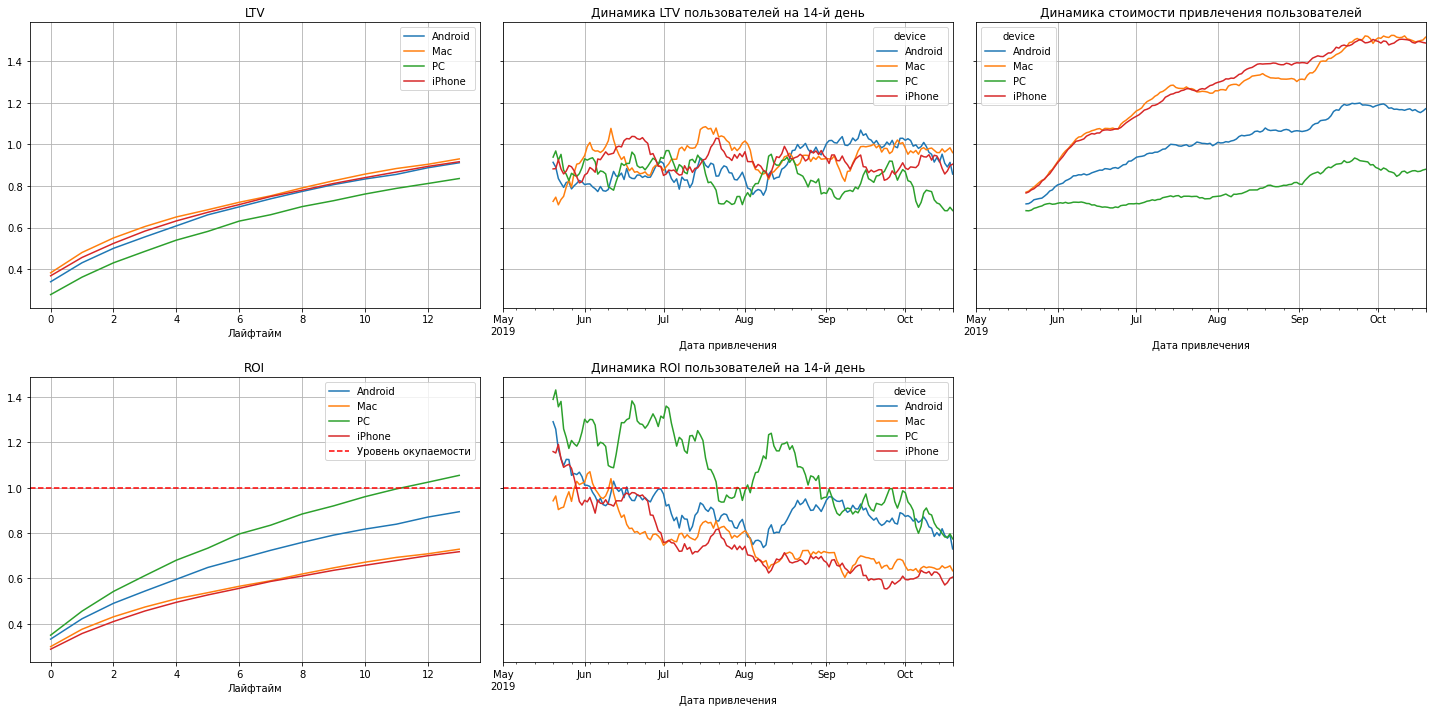

In [ ]:
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    result_profiles, orders, observation_date, horizon_days, dimensions=['device']
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=20
)

**Вывод:**
- LTV пользователей всех устроиств показывает удовлетворительный результат.
- LTV пользователей ПК ниже, чем пользователей с других устройств, при этом окупается только эта категория пользователей.
- При этом стоимость привлечения для данного типа устройств самая дешевая среди всех категорий.
- По динамике ROI мы видим, что с сентября по октябрь окупаемость всех устройств упала ниже уровмя CAC, пользователи ПК окупались самое длительное время.
- По показателям ROI только РС показал результат выше уровня CAC.

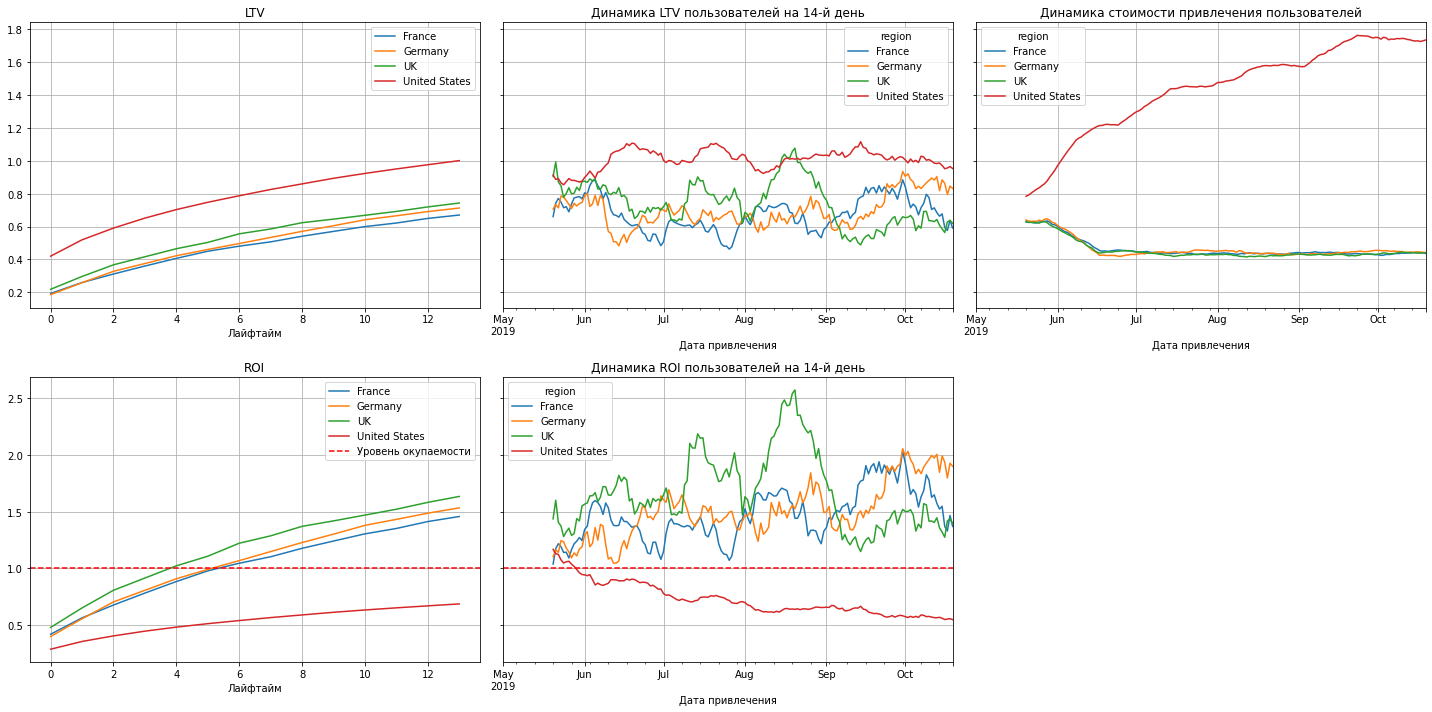

In [ ]:
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    result_profiles, orders, observation_date, horizon_days, dimensions=['region']
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=20
)

**Вывод:**
Теперь все очевидно, первым звонком были показатели удержания по регионам в США, а теперь все встало на свои места.
- Чудовищные затраты на привлечение клиентов из США, при отрицательном показателе ROI.
- Ужасные показатели, как и в динамике ROI, так и в показатели- худший результат среди 4х стран. 

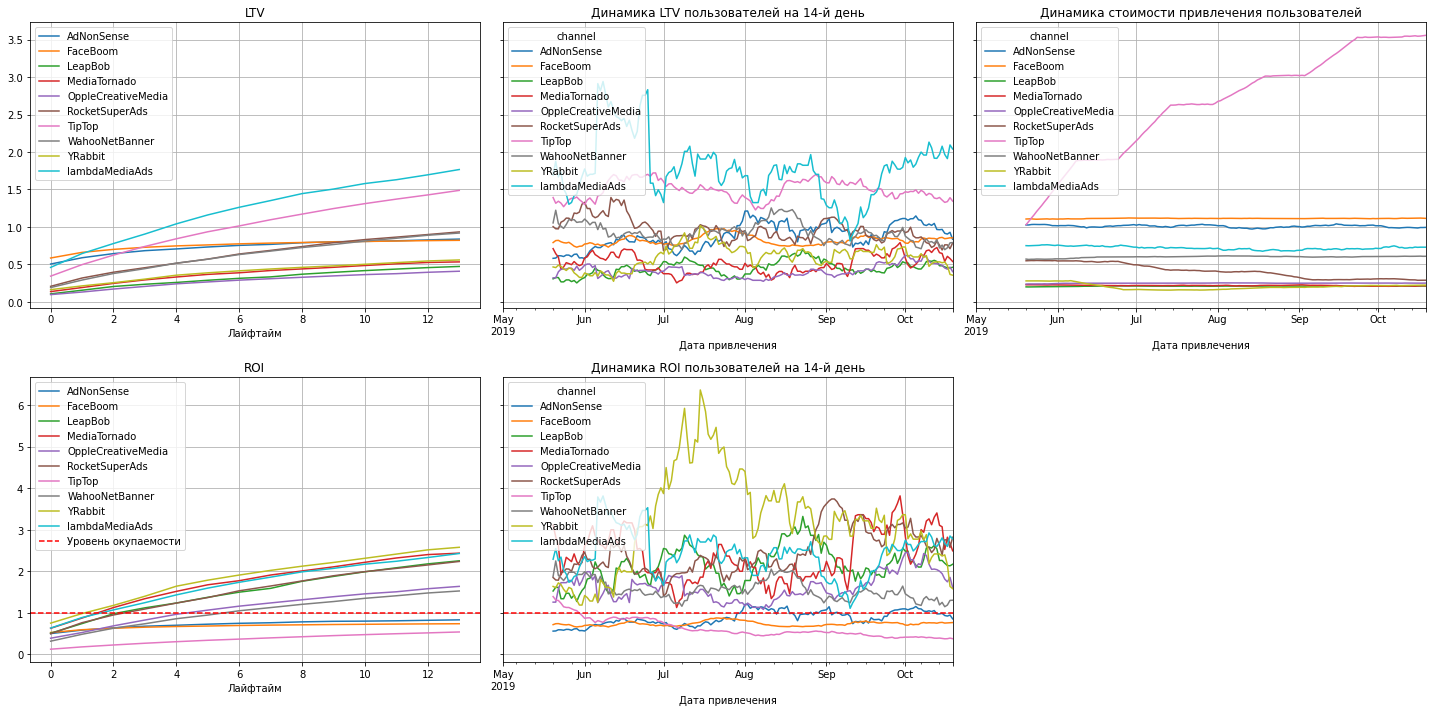

In [ ]:
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    result_profiles, orders, observation_date, horizon_days, dimensions=['channel']
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=20
)

**Вывод:**
- У всех каналов привлечения положительный  LTV.
- Лучшие показатели пользователей привлечены через lambadaMediaAds и TipTop.
- Огромные траты на канал TipTop и как седствие, отрицательный показатель ROI, у привлеченных с этого какнала.
- А окупаемость пользователей, привлечённых с других каналов, показывает положительную рентабельность.

### Общий вывод

Причины неэффективности привлечения пользователей следующие:
- Пользователи США перестали окупаться в тот момент, когдаподскочили траты на рекламу. Реклама оказалась неэффективной, соответственно ROI полетелвниз.
- Мало внимания уделяется владельцам ПК - они удерживаются лучше других, и единственные из всех устройств окупаются к концу второй недели.
- Удержание платящих пользователей из США оказалось хуже остальных.
- Пользователи из каналов TipTop и FaceBoom не окупились по причине больших затрат на рекламу
- Пользователи из канала FaceBoom и AdNoneSense удерживаются хуже других.


### Рекомендации для отдела маркетинга:


- Необходиме сделать акцент на пользователях ПК, их владельцы удерживаются лучше всего и единственные из всех, кто окупает затраты на рекламу, при этом LTV находится ниже, чем у других устройтсв. Необходимо провести мероприятия- улучшенить качество обслуживания, вводить новые программы лояльности и вознаграждения и улучшить пользовательский опыт. 
- Для пользователей Андроид стоит расмотреть стратегию, которая была выстроена для ПК, так как потенциал окупаемости виден, исходя из графика ROI.
- В срочном порядке уменьшить затраты на маркетинг в США.
- Сделать акцент на канал lambadaMediaAds, показатель LTV лучший среди всех каналов.
- Уменьшить затраты на рекламу на каналах Фейсбум и AdNoneSense из-за низкого показателя удержаний клиентов с этого канала.
- Канал привлечения FaceBoom играет важную роль в привлечении платящих пользователей, на FaceBoom было выделено 30.8% от общего бюджета. Эффективность этого канала имеет значение для общей окупаемости, так, если FaceBoom требует на привлечение пользователя 1.1 доллара и доля его платящих— 12.2%. Рекомендуется пересмотреть рекламную стратегию длля этого канала.
- В США большая часть платящих пользователей 77.72%, окупаемость там оказалась ниже всех. По моему мнению интерес пользователей угасал из-за высокой конкуренции в этой стране, также высокие расходы на рекламу и зарплаты, изменение спроса клиентов, качество предоставляемых услуг и самое главное это неэффективное управление ресурсами, что сказалось на общей окупаемости.
- Рекомендуется уволить финансового директора отвечающего за регион США, либо взять его деятельность на серьезный контроль.